# Predicción de Churn — Telecomunicaciones
**CS3061 · Machine Learning · UTEC**

Autores: Carlos Villegas Arce, Diego Illescas, Tulio Huerta

---
1. Sube `train.csv` y `test.csv` a la sesión de Colab (celda de carga abajo).
2. Ejecuta todas las celdas en orden (`Runtime → Run all`).
3. El archivo `submission_final_mejorado.csv` se descargará automáticamente al finalizar.

## 0. Cargar archivos en Colab

In [22]:
from google.colab import files
uploaded = files.upload()  # train.csv y test.csv

KeyboardInterrupt: 

## 1. Importaciones y semilla

In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import (
    f1_score, accuracy_score, confusion_matrix,
    classification_report, roc_curve, auc
)

# Semilla global para replicabilidad
SEED = 42
print('Librerías cargadas correctamente ✓')

Librerías cargadas correctamente ✓


## 2. Carga de datos y exploración básica

In [3]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

y_train_raw = train['Churn'].map({'Yes': 1, 'No': 0})
test_ids    = test['customerID']

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test.shape}')
print(f'\nDistribución Churn:')
print(y_train_raw.value_counts().rename({0:'No (0)', 1:'Yes (1)'}))
print(f'\nDesbalance: {y_train_raw.mean()*100:.1f}% de clientes cancelaron')

Train shape : (5634, 21)
Test  shape : (1409, 20)

Distribución Churn:
Churn
No (0)     4138
Yes (1)    1496
Name: count, dtype: int64

Desbalance: 26.6% de clientes cancelaron


In [4]:
# Vista rápida del dataset
train.head(3)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,4223-BKEOR,Female,0,No,Yes,21,Yes,No,DSL,Yes,...,Yes,No,No,Yes,One year,No,Mailed check,64.85,1336.8,No
1,6035-RIIOM,Female,0,No,No,54,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Two year,Yes,Bank transfer (automatic),97.20,5129.45,No
2,3797-VTIDR,Male,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,23.45,23.45,Yes


In [5]:
# Verificar valores faltantes
nulls = train.isnull().sum()
print('Valores nulos en train:')
print(nulls[nulls > 0] if nulls.sum() > 0 else 'Ninguno ✓')

Valores nulos en train:
Ninguno ✓


## 3. Ingeniería de variables (Feature Engineering)

In [6]:
def engineer_features(df):
    """Crea 6 variables nuevas a partir del dataset original."""
    df_new = df.copy()

    # --- Forzar variables numéricas ---
    for col in ['TotalCharges', 'tenure', 'MonthlyCharges']:
        df_new[col] = pd.to_numeric(df_new[col], errors='coerce').fillna(0)

    # --- Variables de servicios ---
    servicios = [
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies'
    ]
    df_new['num_servicios'] = df_new[servicios].apply(
        lambda x: (x == 'Yes').sum(), axis=1
    )

    # --- Variables financieras ---
    df_new['gasto_promedio_real'] = (
        df_new['TotalCharges'] / df_new['tenure'].clip(lower=1)
    )
    df_new['costo_por_servicio'] = (
        df_new['MonthlyCharges'] / df_new['num_servicios'].clip(lower=1)
    )

    # --- Variables de comportamiento ---
    df_new['cliente_nuevo']    = (df_new['tenure'] <= 3).astype(int)
    df_new['contrato_mensual'] = (df_new['Contract'] == 'Month-to-month').astype(int)
    df_new['fibra_sin_soporte'] = (
        (df_new['InternetService'] == 'Fiber optic') &
        (df_new['TechSupport'] == 'No')
    ).astype(int)

    return df_new.drop(['customerID', 'Churn'], axis=1, errors='ignore')


train_fe = engineer_features(train)
test_fe  = engineer_features(test)

print('Variables creadas:', ['num_servicios','gasto_promedio_real',
      'costo_por_servicio','cliente_nuevo','contrato_mensual','fibra_sin_soporte'])
print(f'Shape train_fe: {train_fe.shape}')

Variables creadas: ['num_servicios', 'gasto_promedio_real', 'costo_por_servicio', 'cliente_nuevo', 'contrato_mensual', 'fibra_sin_soporte']
Shape train_fe: (5634, 25)


## 4. Preprocesamiento

In [21]:
binarias = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binarias:
    train_fe[col] = train_fe[col].map({'Yes': 1, 'No': 0})
    test_fe[col]  = test_fe[col].map({'Yes': 1, 'No': 0})

train_fe['gender'] = train_fe['gender'].map({'Male': 1, 'Female': 0})
test_fe['gender']  = test_fe['gender'].map({'Male': 1, 'Female': 0})

categoricas = [
    'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
    'Contract', 'PaymentMethod'
]

train_encoded = pd.get_dummies(train_fe, columns=categoricas, drop_first=True)
test_encoded  = pd.get_dummies(test_fe,  columns=categoricas, drop_first=True)

X_train_full, X_test = train_encoded.align(
    test_encoded, join='left', axis=1, fill_value=0
)

print(f'Features totales tras encoding: {X_train_full.shape[1]}')

Features totales tras encoding: 36


In [20]:
# Escalado Z-score (fit SOLO sobre train)
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_full),
    columns=X_train_full.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

# Split Train / Validation (80/20 estratificado)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_scaled, y_train_raw,
    test_size=0.2, random_state=SEED, stratify=y_train_raw
)

print(f'X_tr : {X_tr.shape}  |  X_val : {X_val.shape}')
print(f'Churn en val — No: {(y_val==0).sum()} | Yes: {(y_val==1).sum()}')

X_tr : (4507, 36)  |  X_val : (1127, 36)
Churn en val — No: 828 | Yes: 299


## 5. Modelo 1 — Regresión Logística (GridSearchCV, cv=5)

In [9]:
lr_base = LogisticRegression(
    class_weight='balanced', max_iter=3000, random_state=SEED
)

parametros_lr = {
    'C':       [0.001, 0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver':  ['lbfgs', 'liblinear']
}

busqueda_lr = GridSearchCV(
    lr_base, parametros_lr, cv=5, scoring='f1', n_jobs=-1
)
busqueda_lr.fit(X_tr, y_tr)
mejor_lr = busqueda_lr.best_estimator_

print(f'Mejor F1 CV  (LR) : {busqueda_lr.best_score_:.4f}')
print(f'Mejores params LR : {busqueda_lr.best_params_}')

Mejor F1 CV  (LR) : 0.6285
Mejores params LR : {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}


## 6. Modelo 2 — Support Vector Machine (GridSearchCV, cv=3)

In [10]:
svm_base = SVC(
    class_weight='balanced', probability=True, random_state=SEED
)

parametros_svm = {
    'C':      [0.1, 1, 10],
    'kernel': ['rbf', 'linear']
}

busqueda_svm = GridSearchCV(
    svm_base, parametros_svm, cv=3, scoring='f1', n_jobs=-1
)
busqueda_svm.fit(X_tr, y_tr)
mejor_svm = busqueda_svm.best_estimator_

print(f'Mejor F1 CV  (SVM): {busqueda_svm.best_score_:.4f}')
print(f'Mejores params SVM: {busqueda_svm.best_params_}')

Mejor F1 CV  (SVM): 0.6112
Mejores params SVM: {'C': 0.1, 'kernel': 'rbf'}


## 7. Comparativa y selección del mejor modelo

In [11]:
print('=== Comparativa (umbral = 0.5) ===')
for nombre, modelo in [('Logistic Regression', mejor_lr), ('SVM', mejor_svm)]:
    proba = modelo.predict_proba(X_val)[:, 1]
    pred  = (proba >= 0.5).astype(int)
    print(f'  {nombre:22s}: accuracy={accuracy_score(y_val, pred):.4f}  f1={f1_score(y_val, pred):.4f}')

# Selección por F1 en validación cruzada
if busqueda_svm.best_score_ > busqueda_lr.best_score_:
    mejor_modelo  = mejor_svm
    nombre_modelo = 'Support Vector Machine'
else:
    mejor_modelo  = mejor_lr
    nombre_modelo = 'Logistic Regression'

print(f'\n→ Modelo seleccionado: {nombre_modelo}')

=== Comparativa (umbral = 0.5) ===
  Logistic Regression   : accuracy=0.7471  f1=0.6255
  SVM                   : accuracy=0.8066  f1=0.6367

→ Modelo seleccionado: Logistic Regression


## 8. Curva ROC — Comparativa

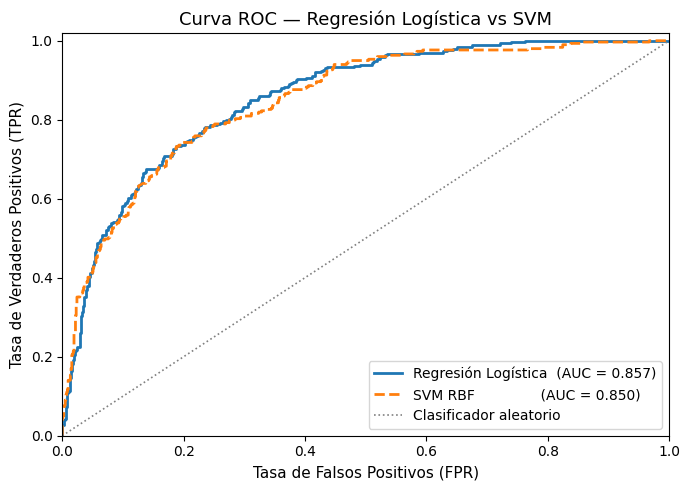

AUC LR=0.857  |  AUC SVM=0.850


In [12]:
y_proba_lr  = mejor_lr.predict_proba(X_val)[:, 1]
y_proba_svm = mejor_svm.predict_proba(X_val)[:, 1]

fpr_lr,  tpr_lr,  _ = roc_curve(y_val, y_proba_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_val, y_proba_svm)
auc_lr  = auc(fpr_lr,  tpr_lr)
auc_svm = auc(fpr_svm, tpr_svm)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr,  tpr_lr,  color='#1f77b4', lw=2,
        label=f'Regresión Logística  (AUC = {auc_lr:.3f})')
ax.plot(fpr_svm, tpr_svm, color='#ff7f0e', lw=2, ls='--',
        label=f'SVM RBF               (AUC = {auc_svm:.3f})')
ax.plot([0, 1], [0, 1], 'gray', ls=':', lw=1.2, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=11)
ax.set_title('Curva ROC — Regresión Logística vs SVM', fontsize=13)
ax.legend(fontsize=10)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig('roc_comparativa.png', dpi=200)
plt.show()
print(f'AUC LR={auc_lr:.3f}  |  AUC SVM={auc_svm:.3f}')

## 9. Optimización del umbral de decisión (F1-Score)

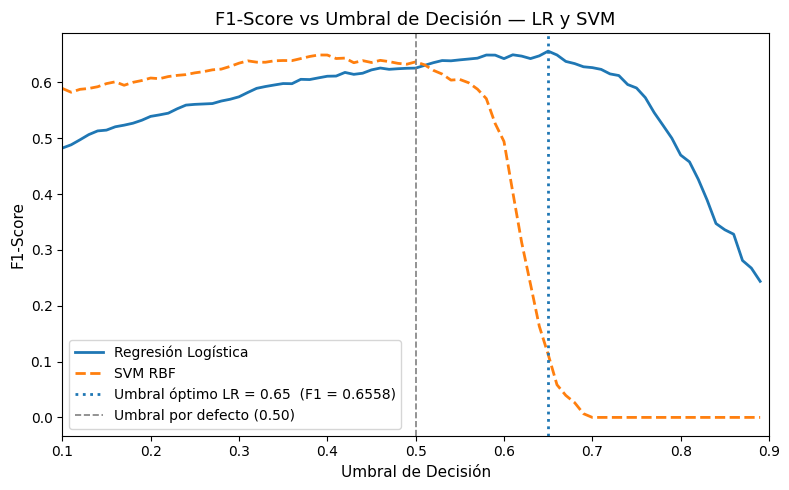

Umbral óptimo: 0.65  |  Mejor F1: 0.6558


In [13]:
y_val_proba = mejor_modelo.predict_proba(X_val)[:, 1]
y_proba_svm_v = mejor_svm.predict_proba(X_val)[:, 1]

umbrales    = np.arange(0.10, 0.90, 0.01)
f1_lr_vals  = [f1_score(y_val, (y_val_proba   >= u).astype(int)) for u in umbrales]
f1_svm_vals = [f1_score(y_val, (y_proba_svm_v >= u).astype(int)) for u in umbrales]

umbral_optimo = umbrales[np.argmax(f1_lr_vals)]
mejor_f1      = max(f1_lr_vals)

fig2, ax2 = plt.subplots(figsize=(8, 5))
ax2.plot(umbrales, f1_lr_vals,  color='#1f77b4', lw=2, label='Regresión Logística')
ax2.plot(umbrales, f1_svm_vals, color='#ff7f0e', lw=2, ls='--', label='SVM RBF')
ax2.axvline(x=umbral_optimo, color='#1f77b4', ls=':', lw=2,
            label=f'Umbral óptimo LR = {umbral_optimo:.2f}  (F1 = {mejor_f1:.4f})')
ax2.axvline(x=0.5, color='gray', ls='--', lw=1.2, label='Umbral por defecto (0.50)')
ax2.set_xlabel('Umbral de Decisión', fontsize=11)
ax2.set_ylabel('F1-Score', fontsize=11)
ax2.set_title('F1-Score vs Umbral de Decisión — LR y SVM', fontsize=13)
ax2.legend(fontsize=10); ax2.set_xlim([0.1, 0.9])
plt.tight_layout()
plt.savefig('f1_vs_umbral.png', dpi=200)
plt.show()
print(f'Umbral óptimo: {umbral_optimo:.2f}  |  Mejor F1: {mejor_f1:.4f}')

## 10. Evaluación final con umbral óptimo

In [14]:
y_pred_optimo = (y_val_proba >= umbral_optimo).astype(int)
acc_final     = accuracy_score(y_val, y_pred_optimo)

print(f'Accuracy (umbral óptimo): {acc_final:.4f}')
print('\nClassification Report:')
print(classification_report(y_val, y_pred_optimo,
      target_names=['Se queda (0)', 'Cancela (1)']))

Accuracy (umbral óptimo): 0.8119

Classification Report:
              precision    recall  f1-score   support

Se queda (0)       0.88      0.86      0.87       828
 Cancela (1)       0.64      0.68      0.66       299

    accuracy                           0.81      1127
   macro avg       0.76      0.77      0.76      1127
weighted avg       0.82      0.81      0.81      1127



## 11. Matriz de Confusión

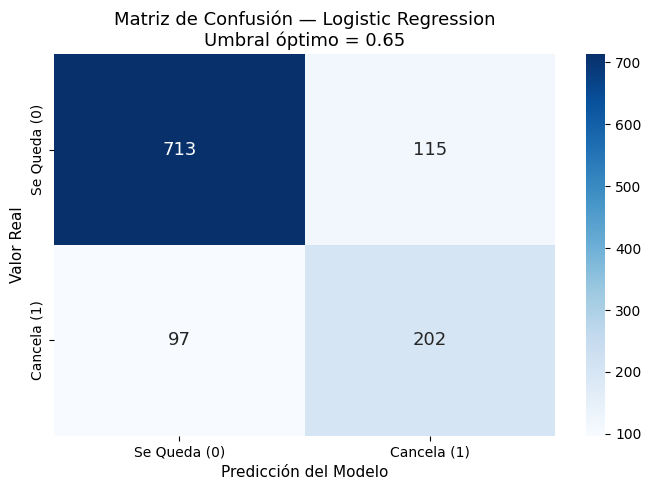

TN=713  FP=115  FN=97  TP=202


In [15]:
matriz = confusion_matrix(y_val, y_pred_optimo)
TN, FP, FN, TP = matriz.ravel()

fig3, ax3 = plt.subplots(figsize=(7, 5))
sns.heatmap(
    matriz, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Se Queda (0)', 'Cancela (1)'],
    yticklabels=['Se Queda (0)', 'Cancela (1)'],
    ax=ax3, annot_kws={'size': 13}
)
ax3.set_title(
    f'Matriz de Confusión — {nombre_modelo}\nUmbral óptimo = {umbral_optimo:.2f}',
    fontsize=13
)
ax3.set_ylabel('Valor Real', fontsize=11)
ax3.set_xlabel('Predicción del Modelo', fontsize=11)
plt.tight_layout()
plt.savefig('matriz_confusion_optima.png', dpi=200)
plt.show()
print(f'TN={TN}  FP={FP}  FN={FN}  TP={TP}')

## 12. Análisis de Costo-Beneficio

In [16]:
COSTO_FP = 10    # campaña de retención innecesaria
COSTO_FN = 100   # pérdida total del cliente

costo_total   = FP * COSTO_FP + FN * COSTO_FN
costo_umbral5 = 202 * COSTO_FP + 119 * COSTO_FN  # referencia con umbral=0.5

print('=== Análisis de Costo-Beneficio ===')
print(f'  FP={FP}  →  ${FP*COSTO_FP:,}')
print(f'  FN={FN}  →  ${FN*COSTO_FN:,}')
print(f'  Costo Total (umbral={umbral_optimo:.2f}): ${costo_total:,}')
print(f'  Costo Total (umbral=0.50)          : ${costo_umbral5:,}')
print(f'  Ahorro por optimización de umbral  : ${costo_umbral5 - costo_total:,} '
      f'({(costo_umbral5-costo_total)/costo_umbral5*100:.1f}%)')

=== Análisis de Costo-Beneficio ===
  FP=115  →  $1,150
  FN=97  →  $9,700
  Costo Total (umbral=0.65): $10,850
  Costo Total (umbral=0.50)          : $13,920
  Ahorro por optimización de umbral  : $3,070 (22.1%)


## 13. Importancia de variables

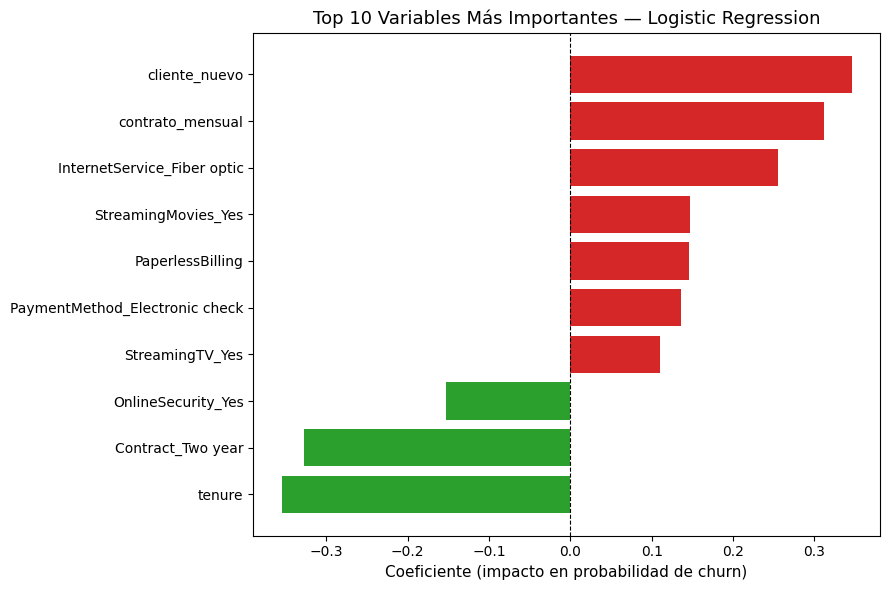

                      Variable      Peso
                        tenure -0.355060
             Contract_Two year -0.327795
            OnlineSecurity_Yes -0.152535
               StreamingTV_Yes  0.110074
PaymentMethod_Electronic check  0.136393
              PaperlessBilling  0.145478
           StreamingMovies_Yes  0.147538
   InternetService_Fiber optic  0.255071
              contrato_mensual  0.312574
                 cliente_nuevo  0.345859


In [17]:
if nombre_modelo == 'Logistic Regression' or \
   (nombre_modelo == 'Support Vector Machine' and mejor_modelo.kernel == 'linear'):

    coeficientes   = mejor_modelo.coef_[0]
    importancia_df = pd.DataFrame({
        'Variable': X_train_full.columns,
        'Peso': coeficientes
    })
    importancia_df['Abs'] = importancia_df['Peso'].abs()
    top_10 = importancia_df.sort_values('Abs', ascending=False).head(10)
    top_10 = top_10.sort_values('Peso', ascending=True)

    colores = ['#d62728' if x > 0 else '#2ca02c' for x in top_10['Peso']]

    fig4, ax4 = plt.subplots(figsize=(9, 6))
    ax4.barh(top_10['Variable'], top_10['Peso'], color=colores)
    ax4.set_title(f'Top 10 Variables Más Importantes — {nombre_modelo}', fontsize=13)
    ax4.set_xlabel('Coeficiente (impacto en probabilidad de churn)', fontsize=11)
    ax4.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
    plt.tight_layout()
    plt.savefig('importancia_variables.png', dpi=200)
    plt.show()
    print(top_10[['Variable', 'Peso']].to_string(index=False))

else:
    print('SVM con kernel no lineal: importancia de variables no disponible directamente.')

## 14. Predicción final y generación del CSV para Kaggle

In [18]:
mejor_modelo.fit(X_train_scaled, y_train_raw)

probabilidades_kaggle = mejor_modelo.predict_proba(X_test_scaled)[:, 1]
predicciones_kaggle   = (probabilidades_kaggle >= umbral_optimo).astype(int)

submission = pd.DataFrame({
    'customerID': test_ids,
    'Churn': predicciones_kaggle
})
submission.to_csv('submission_final_mejorado.csv', index=False)

print('=== Verificación del submission ===')
print(f'  Shape     : {submission.shape}')
print(f'  Columnas  : {list(submission.columns)}')
print(f'  Nulos     : {submission.isnull().sum().to_dict()}')
print(f'  Dist Churn: No={( submission["Churn"]==0).sum()} | Yes={(submission["Churn"]==1).sum()}')
print(f'\nPrimeras 5 filas:')
print(submission.head())

=== Verificación del submission ===
  Shape     : (1409, 2)
  Columnas  : ['customerID', 'Churn']
  Nulos     : {'customerID': 0, 'Churn': 0}
  Dist Churn: No=1002 | Yes=407

Primeras 5 filas:
   customerID  Churn
0  1024-GUALD      1
1  0484-JPBRU      0
2  3620-EHIMZ      0
3  6910-HADCM      1
4  8587-XYZSF      0


In [19]:
# Descargar el archivo desde Colab
from google.colab import files
files.download('submission_final_mejorado.csv')
print('submission_final_mejorado.csv descargado ✓')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

submission_final_mejorado.csv descargado ✓


## Resumen Final

| Métrica | Valor |
|---|---|
| Modelo ganador | Regresión Logística |
| Hiperparámetros | C=0.01, penalty=l2, solver=lbfgs |
| AUC-ROC | 0.857 |
| Umbral óptimo | 0.65 |
| F1-Score (val) | 0.6558 |
| Accuracy (val) | 81.2% |
| Costo Total Esperado | $10,850 |
| Ahorro vs umbral 0.5 | $3,070 (−22%) |